In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
from google.colab import files
uploaded = files.upload()

Saving kh.csv to kh (2).csv


In [23]:
df = pd.read_csv("/content/kh.csv")

In [24]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [25]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [26]:
remaining_nulls = df.isnull().sum()
remaining_nulls

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

CLEAN_PATH = "kh_clean.csv"

In [28]:
def load_clean_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    print(f"[load_clean_data] {df.shape[0]} صف, {df.shape[1]} عمود")
    return df

التشفير (Encoding)

In [29]:
def encode_features(df: pd.DataFrame):
    df = df.drop(columns=["customerID"])


    target_encoder = LabelEncoder()
    y = target_encoder.fit_transform(df["Churn"])
    df = df.drop(columns=["Churn"])

    categorical_cols = df.select_dtypes(include="object").columns.tolist()
    binary_cols = [c for c in categorical_cols if df[c].nunique() == 2]
    multi_cols = [c for c in categorical_cols if df[c].nunique() > 2]

    print(f"[encode_features] (Label Encoding): {binary_cols}")
    print(f"[encode_features] (One-Hot): {multi_cols}")

    # Label Encoding
    for col in binary_cols:
        df[col] = LabelEncoder().fit_transform(df[col])

    # One-Hot Encoding
    df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

    print(f"[encode_features](features)  {df.shape[1]}")
    return df, y, target_encoder


Scaling





In [30]:
def split_and_scale(X: pd.DataFrame, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    print(f"[split_and_scale] Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

    numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
    scaler = StandardScaler()


    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


تعريف الموديلات


In [31]:
def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
        "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    }

تدريب وتقييم كل موديل

In [32]:
def train_and_evaluate(models: dict, X_train, X_test, y_train, y_test) -> pd.DataFrame:
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        })
        print(f"[train_and_evaluate] تم تدريب: {name}")

    results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
    return results_df.reset_index(drop=True)

رسم المقارنة

In [33]:
def plot_comparison(results_df: pd.DataFrame, out_path: str) -> None:
    metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
    melted = results_df.melt(id_vars="Model", value_vars=metrics,
                              var_name="Metric", value_name="Score")

    plt.figure(figsize=(11, 6))
    ax = sns.barplot(data=melted, x="Model", y="Score", hue="Metric")
    ax.set_title("Model Comparison Across Metrics")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=20)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    plt.close()


In [34]:
def plot_best_model_confusion_matrix(model, X_test, y_test, model_name, out_path):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    plt.close()

In [35]:
def main(df: pd.DataFrame):
    # Convert 'TotalCharges' to numeric, coercing errors to NaN
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    # Fill NaN values (which result from empty strings in TotalCharges) with 0,
    # as these usually correspond to customers with 0 tenure.
    df["TotalCharges"].fillna(0, inplace=True)

    X, y, target_encoder = encode_features(df)
    X_train, X_test, y_train, y_test, scaler = split_and_scale(X, y)

    models = get_models()
    results_df = train_and_evaluate(models, X_train, X_test, y_train, y_test)

    print("\n[main] نتائج المقارنة:")
    print(results_df.to_string(index=False))

    plot_comparison(results_df, "model_comparison.png")

    best_name = results_df.iloc[0]["Model"]
    best_model = models[best_name]

    #

    churn_probability = best_model.predict_proba(X_test)[:, 1]
    churn_risk_percentage = churn_probability * 100
    predicted_churn = best_model.predict(X_test)

    # Create a results table while keeping the original customer index
    churn_risk_results = X_test.copy()
    churn_risk_results["Churn_Risk_%"] = churn_risk_percentage
    churn_risk_results["Predicted_Churn"] = predicted_churn

    # Sort from highest to lowest predicted churn risk
    churn_risk_results = churn_risk_results.sort_values(
        "Churn_Risk_%", ascending=False
    )

    churn_risk_results.to_csv("customer_churn_risk.csv", index=True)
    print("\n[main] عرض جميع العملاء حسب نسبة خطورة الـ Churn:")
    display(
        churn_risk_results[["Churn_Risk_%", "Predicted_Churn"]]
    )

    plot_best_model_confusion_matrix(
        best_model, X_test, y_test, best_name, "best_model_confusion_matrix.png"
    )
    print(f"\n[main] أفضل موديل من حيث Accuracy: {best_name} "
          f"({results_df.iloc[0]['Accuracy']:.4f})")

    results_df.to_csv("model_comparison_results.csv", index=False)
    print("[main] تم حفظ النتائج والرسومات بنجاح.")

    return results_df

## تشغيل المشروع كامل
الخلية دي هي اللي فعليًا بتشغّل كل حاجة وترسم الرسومات.

/tmp/ipykernel_1401/3811371082.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(0, inplace=True)


[encode_features] (Label Encoding): ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
[encode_features] (One-Hot): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
[encode_features](features)  30
[split_and_scale] Train: 5634 | Test: 1409
[train_and_evaluate] تم تدريب: Logistic Regression
[train_and_evaluate] تم تدريب: Random Forest
[train_and_evaluate] تم تدريب: Gradient Boosting

[main] نتائج المقارنة:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.806246   0.659306 0.558824  0.604920 0.842171
  Gradient Boosting  0.798439   0.655172 0.508021  0.572289 0.841587
      Random Forest  0.790632   0.634812 0.497326  0.557721 0.824022


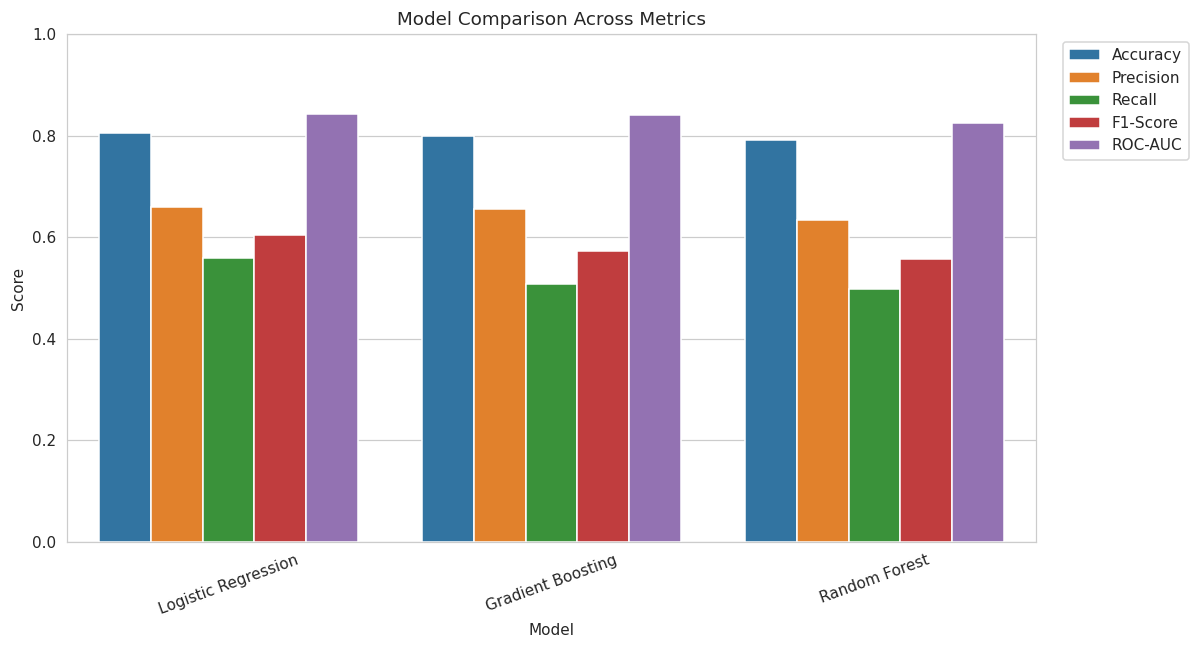


[main] عرض جميع العملاء حسب نسبة خطورة الـ Churn:


,Churn_Risk_%,Predicted_Churn
3380,85.530395,1
6866,83.220566,1
2631,82.788789,1
6365,82.304755,1
4585,81.943602,1
...,...,...
3375,0.180574,0
6614,0.177388,0
4201,0.175493,0
1824,0.174521,0


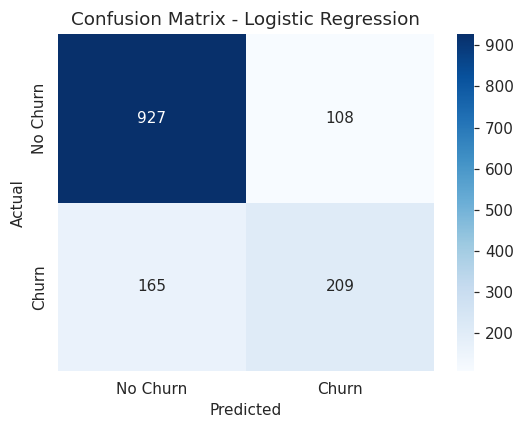


[main] أفضل موديل من حيث Accuracy: Logistic Regression (0.8062)
[main] تم حفظ النتائج والرسومات بنجاح.


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.806246,0.659306,0.558824,0.604920,0.842171
1,Gradient Boosting,0.798439,0.655172,0.508021,0.572289,0.841587
2,Random Forest,0.790632,0.634812,0.497326,0.557721,0.824022


In [36]:
# استدعاء فعلي لدالة main() - من غيرها الكود كله فوق ده معرّف بس مبيتشغلش
results_df = main(df)
results_df


In [37]:
churn_risk_df = pd.read_csv("customer_churn_risk.csv")
# The number of rows in the 'Churn_Risk_%' column is the same as the number of rows in the DataFrame
# (assuming no missing values for this column).
print(f"Number of rows in 'Churn_Risk_%' column: {churn_risk_df['Churn_Risk_%'].shape[0]}")

Number of rows in 'Churn_Risk_%' column: 1409
